In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
img = cv2.imread('pepperImage.png')               # 이미지 불러오기 (BGR 형식)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)    # RGB 형식으로 변환

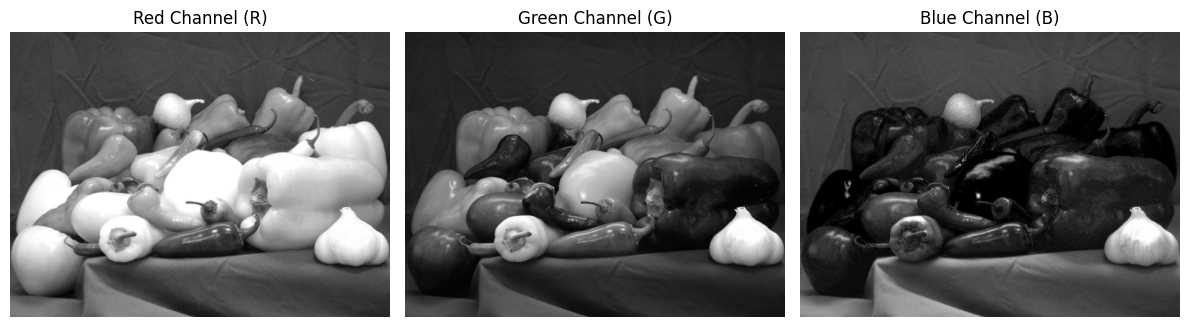

In [12]:
# R, G, B 채널 분리
R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

# 각 채널 그레이스케일로 시각화
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(R, cmap='gray')
plt.title('Red Channel (R)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(G, cmap='gray')
plt.title('Green Channel (G)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(B, cmap='gray')
plt.title('Blue Channel (B)')
plt.axis('off')

plt.tight_layout()
plt.show()

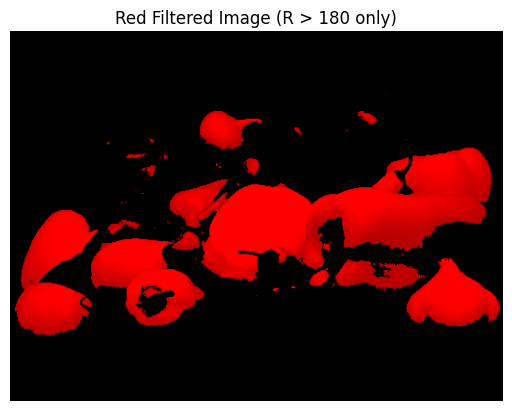

In [13]:
# R, G, B 분리
R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

# R > 180인 값만 남기고 나머지 0으로
R_star = np.where(R > 180, R, 0)

# G*, B*는 모두 0
G_star = np.zeros_like(G)
B_star = np.zeros_like(B)

# 다시 RGB 이미지로 합치기
image_star = np.stack([R_star, G_star, B_star], axis=2)

# 출력
plt.imshow(image_star)
plt.title('Red Filtered Image (R > 180 only)')
plt.axis('off')
plt.show()

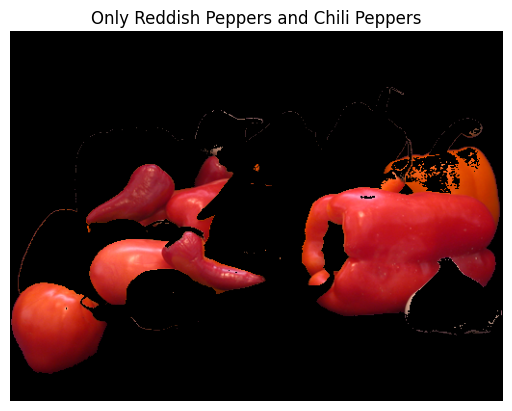

In [15]:
# RGB -> HSV로 변환
image_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# 빨간색 범위 정의 (두 범위로 나눠야 함)
lower_red1 = np.array([0, 70, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 70, 50])
upper_red2 = np.array([180, 255, 255])

# 마스크 생성 (빨간색 부분만 True)
mask1 = cv2.inRange(image_hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(image_hsv, lower_red2, upper_red2)
mask = cv2.bitwise_or(mask1, mask2)

# 마스크를 이용해 원래 이미지에서 빨간색 부분만 추출
result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

# 결과 출력
plt.imshow(result)
plt.title('Only Reddish Peppers and Chili Peppers')
plt.axis('off')
plt.show()

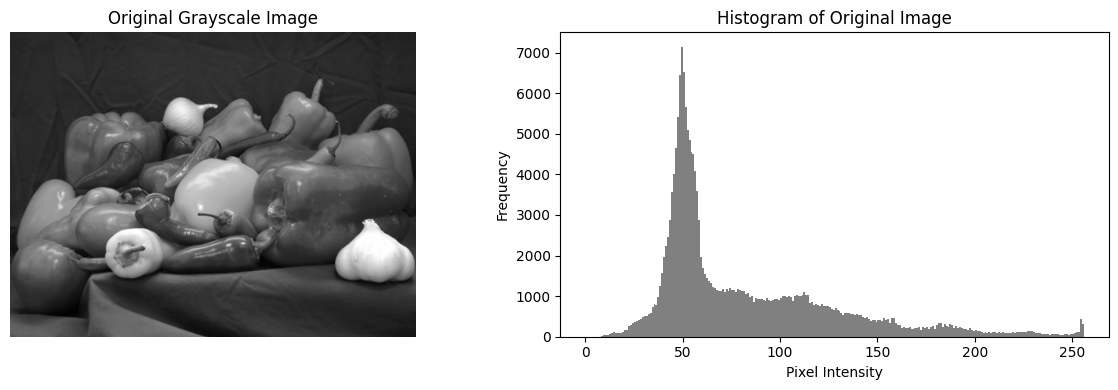

In [16]:
# 1. 컬러 → 그레이스케일 변환
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# 2. 원본 히스토그램 그리기
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(gray.ravel(), bins=256, range=(0, 256), color='gray')
plt.title('Histogram of Original Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

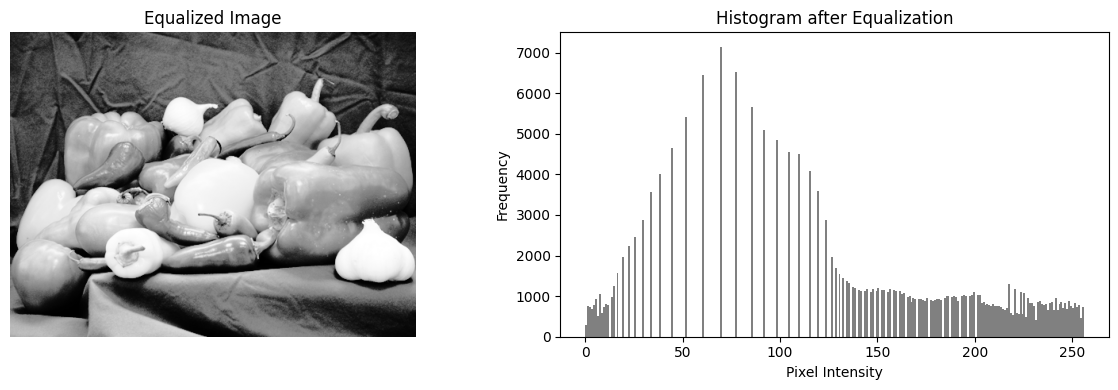

In [17]:
# 3. 히스토그램 평활화
equalized = cv2.equalizeHist(gray)

# 4. 평활화된 이미지 & 히스토그램 출력
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(equalized, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(equalized.ravel(), bins=256, range=(0, 256), color='gray')
plt.title('Histogram after Equalization')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

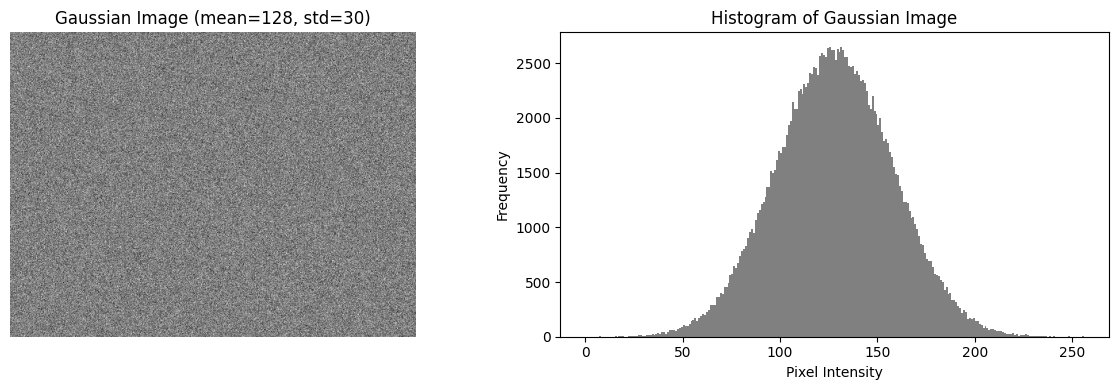

In [18]:
# 이미지 크기 기준 (이전 grayscale 이미지 크기 활용)
height, width = gray.shape

# 평균과 표준편차 설정 (직접 조절 가능)
mean = 128   # 중간 밝기
std_dev = 30 # 퍼짐 정도

# 정규분포를 따르는 픽셀값 생성
gaussian_img = np.random.normal(loc=mean, scale=std_dev, size=(height, width))

# 0~255 범위로 클리핑하고 정수형으로 변환
gaussian_img = np.clip(gaussian_img, 0, 255).astype(np.uint8)

# 이미지와 히스토그램 출력
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(gaussian_img, cmap='gray')
plt.title(f'Gaussian Image (mean={mean}, std={std_dev})')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(gaussian_img.ravel(), bins=256, range=(0, 256), color='gray')
plt.title('Histogram of Gaussian Image')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()